# Plant disease dataset exploration
This notebook performs dataset loading, class analysis, and visualization for the PlantVillage dataset.

In [27]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from pathlib import Path

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.optimizers import Adam

In [28]:
# Set dataset path correctly (use = not :)
DATASET_PATH = Path("../dataset/raw")
# Sanity checks
if not DATASET_PATH.exists():
    raise FileNotFoundError(f"Dataset path not found: {DATASET_PATH.resolve()}")
# Build class list from directories inside dataset path
classes = sorted([p.name for p in DATASET_PATH.iterdir() if p.is_dir()])

print("Dataset path:", DATASET_PATH.resolve())
print("Total classes:", len(classes))
print("First 10 classes:", classes[:10])

Dataset path: /Users/cobbyiswinning/Documents/Class material/Pattern Recognition/plant-disease-detection/backend/dataset/raw
Total classes: 16
First 10 classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'PlantVillage', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold']


# The dataset path

#Class loading

In [29]:
# classes is now defined by the dataset-path cell above
classes = sorted(classes)

print("Total classes:", len(classes))
print("First 10 classes:", classes[:10])

Total classes: 16
First 10 classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'PlantVillage', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold']


# Image count per each class

In [30]:
class_counts = {}

for cls in classes:
    class_path = os.path.join(DATASET_PATH, cls)
    if os.path.isdir(class_path):
        class_counts[cls] = len(os.listdir(class_path))

class_counts = dict(sorted(class_counts.items(), key=lambda x: x[1], reverse=True))

class_counts

{'Tomato__Tomato_YellowLeaf__Curl_Virus': 3209,
 'Tomato_Bacterial_spot': 2127,
 'Tomato_Late_blight': 1909,
 'Tomato_Septoria_leaf_spot': 1771,
 'Tomato_Spider_mites_Two_spotted_spider_mite': 1676,
 'Tomato_healthy': 1591,
 'Pepper__bell___healthy': 1478,
 'Tomato__Target_Spot': 1404,
 'Potato___Early_blight': 1000,
 'Potato___Late_blight': 1000,
 'Tomato_Early_blight': 1000,
 'Pepper__bell___Bacterial_spot': 997,
 'Tomato_Leaf_Mold': 952,
 'Tomato__Tomato_mosaic_virus': 373,
 'Potato___healthy': 152,
 'PlantVillage': 15}

# Table form

In [31]:
df = pd.DataFrame(list(class_counts.items()), columns=["Class", "Image Count"])
df.head()

,Class,Image Count
0,Tomato__Tomato_YellowLeaf__Curl_Virus,3209
1,Tomato_Bacterial_spot,2127
2,Tomato_Late_blight,1909
3,Tomato_Septoria_leaf_spot,1771
4,Tomato_Spider_mites_Two_spotted_spider_mite,1676


# Dataset stats

In [32]:
total_images = sum(class_counts.values())
num_classes = len(class_counts)

largest_class = max(class_counts, key=class_counts.get)
smallest_class = min(class_counts, key=class_counts.get)

print("Total Images:", total_images)
print("Total Classes:", num_classes)
print("Largest Class:", largest_class, class_counts[largest_class])
print("Smallest Class:", smallest_class, class_counts[smallest_class])

Total Images: 20654
Total Classes: 16
Largest Class: Tomato__Tomato_YellowLeaf__Curl_Virus 3209
Smallest Class: PlantVillage 15


#Class Distribution slot

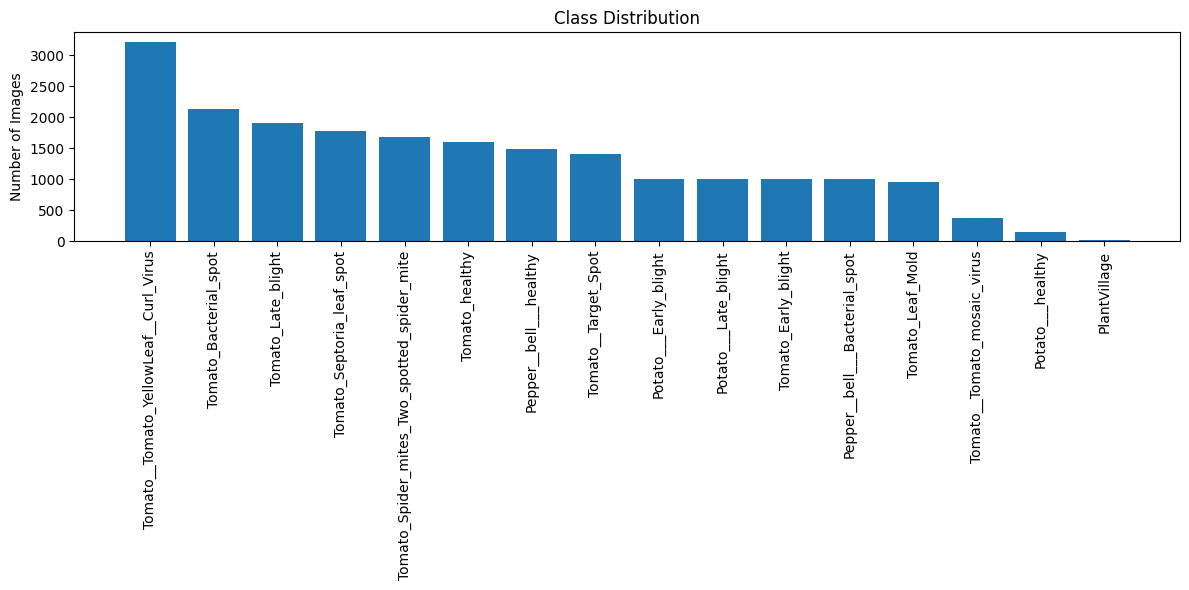

In [33]:
plt.figure(figsize=(12, 6))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=90)
plt.title("Class Distribution")
plt.ylabel("Number of Images")
plt.tight_layout()

plt.savefig("../results/figures/class_distribution.png")
plt.show()

# Sample image per class

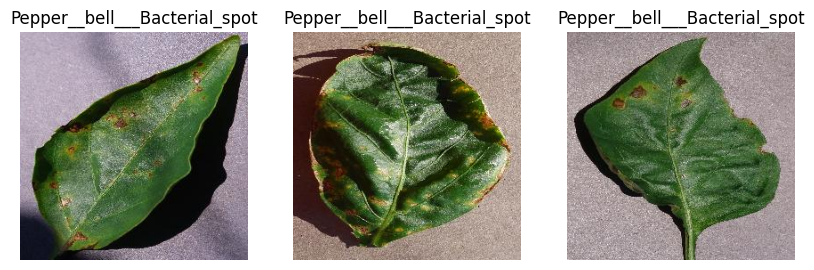

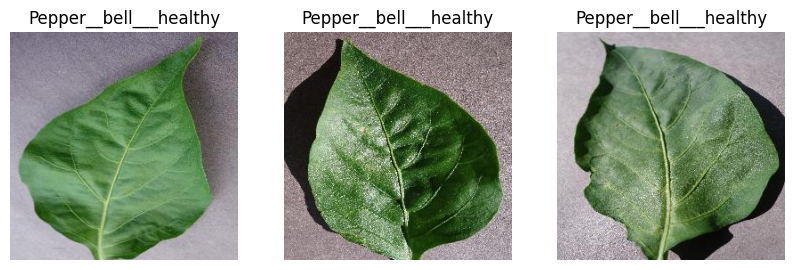

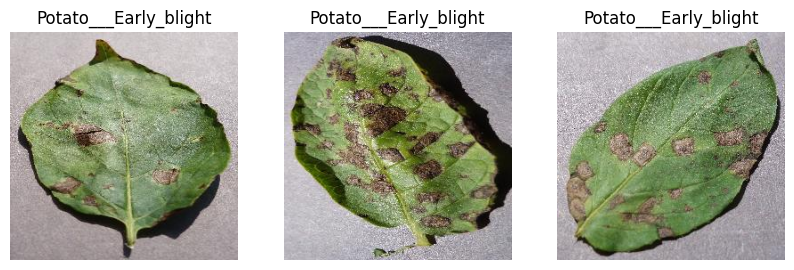

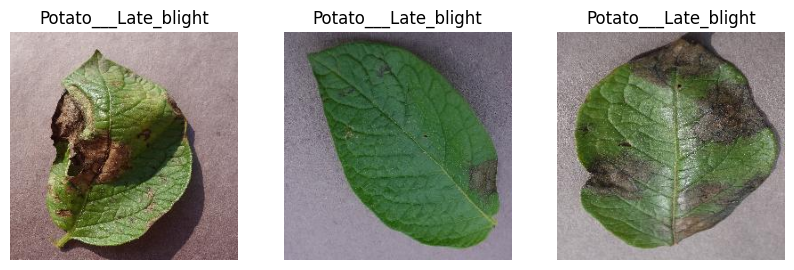

In [34]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

valid_ext = (".jpg", ".jpeg", ".png")

SAMPLE_DIR = "../results/figures/samples"
os.makedirs(SAMPLE_DIR, exist_ok=True)

for cls in classes[:5]:  # limit first 5 for now
    class_path = os.path.join(DATASET_PATH, cls)

    # filter only image files
    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(valid_ext)
    ]

    # safety check (prevents crash if class is weird/empty)
    if len(images) < 3:
        continue

    sample_images = random.sample(images, 3)

    plt.figure(figsize=(10, 3))

    for i, img_name in enumerate(sample_images):
        img_path = os.path.join(class_path, img_name)

        img = mpimg.imread(img_path)

        plt.subplot(1, 3, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(cls)

    save_path = os.path.join(SAMPLE_DIR, f"{cls}.png")
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()

# Save summary file

In [35]:
summary_text = f"""
Dataset Summary
---------------
Total Images: {total_images}
Total Classes: {num_classes}
Largest Class: {largest_class} ({class_counts[largest_class]})
Smallest Class: {smallest_class} ({class_counts[smallest_class]})
"""

with open("../results/dataset_summary.txt", "w") as f:
    f.write(summary_text)

print(summary_text)


Dataset Summary
---------------
Total Images: 20654
Total Classes: 16
Largest Class: Tomato__Tomato_YellowLeaf__Curl_Virus (3209)
Smallest Class: PlantVillage (15)



# Image processing (Resize, Normalize, Augmentation, Split)

In [36]:
IMG_SIZE = 224
BATCH_SIZE = 32

In [37]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data augmentation cell

In [38]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,

    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# Train and validate

In [39]:
train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 33027 images belonging to 16 classes.
Found 8249 images belonging to 16 classes.


In [40]:
import sys

print("Python Executable:")
print(sys.executable)

print("\nPython Version:")
print(sys.version)

Python Executable:
/Users/cobbyiswinning/Documents/Class material/Pattern Recognition/plant-disease-detection/backend/venv/bin/python

Python Version:
3.11.15 (main, Mar  3 2026, 00:52:57) [Clang 21.0.0 (clang-2100.0.123.102)]


# Image Size

In [41]:
IMG_SIZE = 224
BATCH_SIZE = 32
DATASET_PATH = "../dataset/raw"  # adjust if needed

# Train augmentation pipeline

In [42]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,

    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

# Validation pipeline

In [43]:
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Training generator

In [44]:
train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

Found 33027 images belonging to 16 classes.


# Validation generator

In [45]:
val_generator = val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

Found 8249 images belonging to 16 classes.


# Sanity check

In [46]:
print(train_generator.class_indices)
print("Classes:", len(train_generator.class_indices))

{'Pepper__bell___Bacterial_spot': 0, 'Pepper__bell___healthy': 1, 'PlantVillage': 2, 'Potato___Early_blight': 3, 'Potato___Late_blight': 4, 'Potato___healthy': 5, 'Tomato_Bacterial_spot': 6, 'Tomato_Early_blight': 7, 'Tomato_Late_blight': 8, 'Tomato_Leaf_Mold': 9, 'Tomato_Septoria_leaf_spot': 10, 'Tomato_Spider_mites_Two_spotted_spider_mite': 11, 'Tomato__Target_Spot': 12, 'Tomato__Tomato_YellowLeaf__Curl_Virus': 13, 'Tomato__Tomato_mosaic_virus': 14, 'Tomato_healthy': 15}
Classes: 16


# Batch check

In [47]:
x_batch, y_batch = next(train_generator)

print(x_batch.shape)
print(y_batch.shape)

(32, 224, 224, 3)
(32, 16)


# Build Model

In [48]:
num_classes = len(train_generator.class_indices)

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

/Users/cobbyiswinning/Documents/Class material/Pattern Recognition/plant-disease-detection/backend/venv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Compile

In [49]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Summary

In [50]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │         2,064 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,171,024 (42.61 MB)

 Trainable params: 11,171,024 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

# Train

In [51]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 336s 324ms/step - accuracy: 0.4960 - loss: 1.8000 - val_accuracy: 0.4124 - val_loss: 1.5977
Epoch 2/10
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 332s 322ms/step - accuracy: 0.5119 - loss: 1.4425 - val_accuracy: 0.2194 - val_loss: 2.1047
Epoch 3/10
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 336s 325ms/step - accuracy: 0.5207 - loss: 1.2890 - val_accuracy: 0.2182 - val_loss: 2.2225
Epoch 4/10
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 340s 329ms/step - accuracy: 0.5259 - loss: 1.2080 - val_accuracy: 0.1729 - val_loss: 2.8101
Epoch 5/10
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 347s 336ms/step - accuracy: 0.5325 - loss: 1.1433 - val_accuracy: 0.1639 - val_loss: 2.9672
Epoch 6/10
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 364s 352ms/step - accuracy: 0.5356 - loss: 1.1106 - val_accuracy: 0.1968 - val_loss: 2.7752
Epoch 7/10
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 368s 356ms/step - accuracy: 0.5384 - loss: 1.0777 - val_accuracy: 0.1924 - val_loss: 2.9391
Epoch 8/10
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 368s 355ms/step - ac

# Save model

In [35]:
model.save("../saved_models/cnn_baseline.keras")

# Final Metrics

In [ ]:
print("Final Training Accuracy:", history.history["accuracy"][-1])
print("Final Validation Accuracy:", history.history["val_accuracy"][-1])

print("Final Training Loss:", history.history["loss"][-1])
print("Final Validation Loss:", history.history["val_loss"][-1])

# Accuracy Curve

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.savefig("../results/figures/cnn_accuracy.png")

plt.show()

# Loss Curve

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.savefig("../results/figures/cnn_loss.png")

plt.show()

# Generate Predictions

In [ ]:
val_generator.reset()

predictions = model.predict(val_generator)

y_pred = predictions.argmax(axis=1)
y_true = val_generator.classes

# Class report

In [ ]:
class_names = list(val_generator.class_indices.keys())

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)

# Save class report

In [ ]:
with open("../results/classification_report.txt", "w") as f:
    f.write(report)

# Confusion Metrics

In [ ]:
cm = confusion_matrix(y_true, y_pred)

# Plot confusion metrics

In [ ]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.savefig("../results/figures/confusion_matrix.png")

plt.show()

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import json

# 1. Setup Data Generators for MobileNetV2
# MobileNetV2 expects inputs in range [-1, 1], so we use its specific preprocess_input
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

train_datagen_tl = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen_tl = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_generator_tl = train_datagen_tl.flow_from_directory(
    DATASET_PATH,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator_tl = val_datagen_tl.flow_from_directory(
    DATASET_PATH,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

# 2. Build MobileNetV2 Transfer Learning Model
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze the base layers

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(len(train_generator_tl.class_indices), activation='softmax')(x)

tl_model = Model(inputs=base_model.input, outputs=predictions)

tl_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 3. Training Callbacks
callbacks = [
    ModelCheckpoint('../backend/saved_models/mobilenetv2_best.keras', save_best_only=True, monitor='val_accuracy'),
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.2, patience=3)
]

# 4. Train
print("Starting Transfer Learning Training...")
history_tl = tl_model.fit(
    train_generator_tl,
    validation_data=val_generator_tl,
    epochs=15,
    callbacks=callbacks
)

# 5. FINAL STEP: Save the class mapping JSON (Vital for the Backend)
with open('../backend/saved_models/class_indices_mobilenetv2.json', 'w') as f:
    json.dump(train_generator_tl.class_indices, f)

print("\n--- TRAINING COMPLETE ---")
print("Model saved to: ../backend/saved_models/mobilenetv2_best.keras")
print("Class mapping saved to: ../backend/saved_models/class_indices_mobilenetv2.json")